# Book 4 — Gaussian Process Uncertainty and Calibration

This notebook adds a probabilistic baseline to the RF/XGBoost and GraphSAGE results. It runs in Google Colab after Book 2 has saved the labelled grid table and, optionally, after Book 3 has saved graph predictions.

**Input**: Book 2 labelled grids and feature columns, plus prediction maps from Books 2 and 3 if available.  
**Output**: Gaussian Process predictions, entropy maps, reliability diagrams, Expected Calibration Error (ECE), and a four-model probability comparison.  
**Runtime**: typically 15-35 minutes on Colab; the GP is trained on a stratified subsample to avoid the cubic cost of full Gaussian Processes.  
**Role in the pipeline**: evaluates whether a course-aligned probabilistic model provides useful uncertainty information, rather than replacing GraphSAGE as the headline classifier.


### Step 0: Mount Google Drive

**Purpose**: Connect Colab to the processed Book 2 files and the shared output directory.  
**Input**: Google Drive authentication.  
**Output**: mounted Drive path for GP inputs and output figures.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Step 1: Import libraries and define class constants

**Purpose**: Load the Gaussian Process, geospatial, plotting, and metric libraries used for probabilistic evaluation.  
**Input**: Colab runtime.  
**Output**: imports, random seed, and the same three-class label scheme used in Books 2 and 3.


In [4]:
# ----------------------------------------------------------------------------
# 1. Install and import packages
# ----------------------------------------------------------------------------

!pip -q install geopandas shapely pyproj rtree scikit-learn codecarbon

from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd

from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import ConstantKernel, RBF
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    balanced_accuracy_score,
)
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns

try:
    from codecarbon import EmissionsTracker
    CODECARBON_AVAILABLE = True
except Exception:
    CODECARBON_AVAILABLE = False

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

CLASS_GREEN = 0
CLASS_NORMAL = 1
CLASS_VILLAGE = 2
CLASS_ORDER = [CLASS_GREEN, CLASS_NORMAL, CLASS_VILLAGE]
CLASS_NAMES = {
    CLASS_GREEN: "urban_green",
    CLASS_NORMAL: "normal_built_up",
    CLASS_VILLAGE: "urban_village",
}
CLASS_LABELS_ORDERED = [CLASS_NAMES[c] for c in CLASS_ORDER]


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 380.5/380.5 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 92.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 105.8 MB/s eta 0:00:00


### Step 2: Define Book 4 paths

**Purpose**: Locate the labelled grid file and feature-column list produced by Book 2.  
**Input**: project Drive directory.  
**Output**: path variables and existence checks for the required processed inputs.


In [5]:
# ----------------------------------------------------------------------------
# 2. Mount Drive and define paths
# ----------------------------------------------------------------------------

from google.colab import drive
drive.mount("/content/drive")

PROJECT_DIR = Path("/content/drive/MyDrive/0069/week10")
PROCESSED_DIR = PROJECT_DIR / "processed"
OUTPUT_DIR = PROJECT_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

LABELLED_GEOJSON = PROCESSED_DIR / "book2_labelled_grid_features.geojson"
FEATURE_COLS_JSON = PROCESSED_DIR / "book3_feature_cols.json"

print("Project dir:", PROJECT_DIR)
print("Labelled grid file exists:", LABELLED_GEOJSON.exists())
print("Feature column file exists:", FEATURE_COLS_JSON.exists())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project dir: /content/drive/MyDrive/0069/week10
Labelled grid file exists: True
Feature column file exists: True


### Step 3: Load labelled grids and feature columns

**Purpose**: Reuse the same training labels and predictors as the previous models so GP results are comparable.  
**Input**: `book2_labelled_grid_features.geojson` and `book3_feature_cols.json`.  
**Output**: filtered GeoDataFrame containing only the three supervised classes.


In [6]:
# ----------------------------------------------------------------------------
# 3. Load Book 2 labelled grid features
# ----------------------------------------------------------------------------
# Book 4 runs after Book 2. We reuse the exact labelled dataset and feature
# columns so that GP uncertainty is comparable with RF/XGBoost.

if not LABELLED_GEOJSON.exists():
    raise FileNotFoundError(
        "Book 2 labelled GeoJSON not found. Run Book 2 first:\n"
        f"{LABELLED_GEOJSON}"
    )

if not FEATURE_COLS_JSON.exists():
    raise FileNotFoundError(
        "Feature column list not found. Run Book 2 through the Book 3 export cell first:\n"
        f"{FEATURE_COLS_JSON}"
    )

gdf = gpd.read_file(LABELLED_GEOJSON)
with open(FEATURE_COLS_JSON, "r") as f:
    feature_cols = json.load(f)

gdf = gdf[gdf["weak_label"].isin(CLASS_ORDER)].copy()
print(gdf.shape)
print(gdf["city"].value_counts())
print(gdf["weak_label"].value_counts().sort_index())


(127899, 87)
city
shanghai     33249
tianjin      18346
beijing      15122
guangzhou    13785
chengdu      11830
dongguan      9812
shenzhen      8877
xian          6664
wuhan         5836
chongqing     4378
Name: count, dtype: int64
weak_label
0     11249
1    115246
2      1404
Name: count, dtype: int64


### Step 4: Prepare features with S1-aware missing-value handling

**Purpose**: Build the GP feature matrix while respecting the special meaning of missing Sentinel-1 orbit observations.  
**Input**: labelled grids and feature-column list.  
**Output**: imputed `X_all`, `y_all`, and final usable feature list.


In [7]:
# ----------------------------------------------------------------------------
# 4. Prepare features with S1-aware missing-value handling
# ----------------------------------------------------------------------------
# Same semantics as Book 2:
# - Sentinel-1 missing values mean "this orbit pass has no observation"
#   so fill S1 bands with 0 and rely on s1_*_has_data flags.
# - Other numeric features use median imputation.

X_all = gdf[feature_cols].replace([np.inf, -np.inf], np.nan)
y_all = gdf["weak_label"].astype(int)

s1_cols = [c for c in feature_cols if c.startswith("s1_")]
non_s1_cols = [c for c in feature_cols if c not in s1_cols]

if s1_cols:
    X_all[s1_cols] = X_all[s1_cols].fillna(0)

drop_all_missing_non_s1 = [c for c in non_s1_cols if X_all[c].isna().all()]
if drop_all_missing_non_s1:
    print("Dropping all-missing non-S1 features:", drop_all_missing_non_s1)
    X_all = X_all.drop(columns=drop_all_missing_non_s1)
    feature_cols = [c for c in feature_cols if c not in drop_all_missing_non_s1]
    non_s1_cols = [c for c in non_s1_cols if c not in drop_all_missing_non_s1]

if non_s1_cols:
    X_all[non_s1_cols] = X_all[non_s1_cols].fillna(X_all[non_s1_cols].median(numeric_only=True))

remaining_nan_cols = [c for c in feature_cols if X_all[c].isna().any()]
if remaining_nan_cols:
    print("Dropping features that still contain NaN:", remaining_nan_cols)
    X_all = X_all.drop(columns=remaining_nan_cols)
    feature_cols = [c for c in feature_cols if c not in remaining_nan_cols]

print("Usable features:", len(feature_cols))


Usable features: 75


### Step 5: Create the cross-city split and GP subsample

**Purpose**: Match Book 2's held-out city evaluation while keeping GP training computationally feasible.  
**Input**: full feature matrix and city labels.  
**Output**: train/test matrices and a stratified training subsample capped at `MAX_PER_CLASS`.


In [8]:
# ----------------------------------------------------------------------------
# 5. Cross-city split and stratified GP subsample
# ----------------------------------------------------------------------------
# We keep the same final transfer setting as Book 2:
# train on pilot cities, test on held-out cities. The GP is trained on a
# stratified subsample from the training cities to control O(n^3) cost.

available_cities = sorted(gdf["city"].unique())
TRAIN_CITIES = [c for c in ["guangzhou", "shenzhen", "tianjin", "beijing", "xian", "chongqing"] if c in available_cities]
TEST_CITIES = [c for c in ["dongguan", "shanghai", "chengdu", "wuhan"] if c in available_cities]

if len(TRAIN_CITIES) >= 1 and len(TEST_CITIES) >= 1:
    train_mask = gdf["city"].isin(TRAIN_CITIES).values
    test_mask = gdf["city"].isin(TEST_CITIES).values
    split_name = f"cross_city_train_{'_'.join(TRAIN_CITIES)}_test_{'_'.join(TEST_CITIES)}"
else:
    from sklearn.model_selection import train_test_split
    idx = np.arange(len(gdf))
    train_idx, test_idx = train_test_split(
        idx,
        test_size=0.30,
        stratify=y_all,
        random_state=RANDOM_STATE,
    )
    train_mask = np.zeros(len(gdf), dtype=bool)
    test_mask = np.zeros(len(gdf), dtype=bool)
    train_mask[train_idx] = True
    test_mask[test_idx] = True
    split_name = "stratified_random_split"

X_train_full = X_all.loc[train_mask].copy()
y_train_full = y_all.loc[train_mask].copy()
X_test = X_all.loc[test_mask].copy()
y_test = y_all.loc[test_mask].copy()
test_gdf = gdf.loc[test_mask].copy()

print(split_name)
print("Full train:", X_train_full.shape, y_train_full.value_counts().to_dict())
print("Test:", X_test.shape, y_test.value_counts().to_dict())

MAX_PER_CLASS = 700

def stratified_subsample_indices(y: pd.Series, max_per_class: int, seed: int) -> np.ndarray:
    rng = np.random.default_rng(seed)
    selected = []
    for cls in CLASS_ORDER:
        cls_idx = y[y == cls].index.to_numpy()
        if len(cls_idx) == 0:
            continue
        n = min(max_per_class, len(cls_idx))
        selected.extend(rng.choice(cls_idx, size=n, replace=False).tolist())
    return np.array(selected)

sub_idx = stratified_subsample_indices(y_train_full, MAX_PER_CLASS, RANDOM_STATE)
X_train = X_train_full.loc[sub_idx].copy()
y_train = y_train_full.loc[sub_idx].copy()

print("GP subsample:", X_train.shape, y_train.value_counts().to_dict())
if y_train.nunique() < len(CLASS_ORDER):
    raise ValueError(
        f"GP training subsample does not contain all {len(CLASS_ORDER)} classes. "
        "Check Book 2 weak-label thresholds before running Book 4."
    )


cross_city_train_guangzhou_shenzhen_tianjin_beijing_xian_chongqing_test_dongguan_shanghai_chengdu_wuhan
Full train: (67172, 75) {1: 59900, 0: 6229, 2: 1043}
Test: (60727, 75) {1: 55346, 0: 5020, 2: 361}
GP subsample: (2100, 75) {0: 700, 1: 700, 2: 700}


### Step 6: Train the Gaussian Process classifier

**Purpose**: Fit a fixed-kernel GaussianProcessClassifier as a probabilistic baseline.  
**Input**: standardised subsampled training features and labels.  
**Output**: trained GP model, test probabilities, and predicted classes.


In [9]:
# ----------------------------------------------------------------------------
# 6. Train Gaussian Process classifier
# ----------------------------------------------------------------------------
# We standardise features and use a fixed RBF kernel. Fixing kernel
# hyperparameters avoids expensive high-dimensional kernel optimisation and
# makes the GP a stable uncertainty baseline under Colab constraints.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

kernel = ConstantKernel(1.0, constant_value_bounds="fixed") * RBF(
    length_scale=1.0,
    length_scale_bounds="fixed",
)

gp = GaussianProcessClassifier(
    kernel=kernel,
    optimizer=None,
    multi_class="one_vs_rest",
    n_jobs=-1,
    max_iter_predict=100,
    random_state=RANDOM_STATE,
)

tracker = None
if CODECARBON_AVAILABLE:
    tracker = EmissionsTracker(
        project_name="0069_urban_village_gp_uncertainty",
        output_dir=str(OUTPUT_DIR),
        output_file="book4_codecarbon_emissions.csv",
        log_level="error",
    )
    tracker.start()

gp.fit(X_train_scaled, y_train)

if tracker is not None:
    emissions = tracker.stop()
    print("Estimated emissions kgCO2e:", emissions)

gp_proba = gp.predict_proba(X_test_scaled)
gp_pred = gp.classes_[np.argmax(gp_proba, axis=1)]

print("Trained GP:", gp.kernel_)


[codecarbon WARNING @ 00:33:03] Multiple instances of codecarbon are allowed to run at the same time.


Estimated emissions kgCO2e: 6.000585433103078e-05
Trained GP: CompoundKernel()


### Step 7: Evaluate GP classification and export uncertainty map

**Purpose**: Measure GP performance using the same class metrics and map predictive uncertainty through entropy.  
**Input**: GP predictions, probabilities, and test-grid geometries.  
**Output**: metric CSV, confusion matrix, and GeoJSON prediction map with per-class probabilities.


{'model': 'GP_subsample_GPC', 'split': 'cross_city_train_guangzhou_shenzhen_tianjin_beijing_xian_chongqing_test_dongguan_shanghai_chengdu_wuhan', 'train_subsample_n': 2100, 'max_per_class': 700, 'macro_f1': 0.5274374509552368, 'weighted_f1': 0.8389519553032541, 'balanced_acc': np.float64(0.8278472547703339), 'macro_precision': 0.5139193520636117, 'macro_recall': 0.8278472547703339, 'f1_urban_green': np.float64(0.6607379097457005), 'f1_normal_built_up': np.float64(0.8601881005512589), 'f1_urban_village': np.float64(0.06138634256875064)}
                 precision    recall  f1-score   support

    urban_green      0.524     0.895     0.661      5020
normal_built_up      0.986     0.763     0.860     55346
  urban_village      0.032     0.825     0.061       361

       accuracy                          0.774     60727
      macro avg      0.514     0.828     0.527     60727
   weighted avg      0.942     0.774     0.839     60727



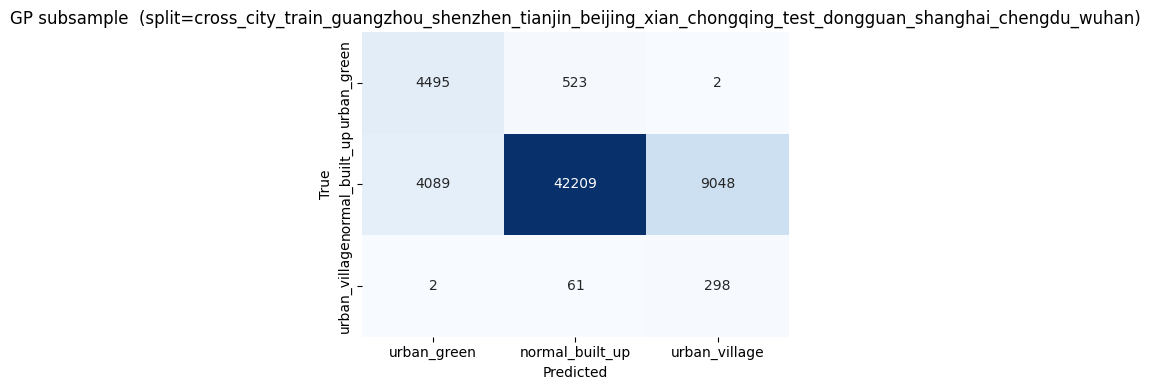

Saved GP uncertainty map: /content/drive/MyDrive/0069/week10/outputs/book4_gp_predictions_cross_city_train_guangzhou_shenzhen_tianjin_beijing_xian_chongqing_test_dongguan_shanghai_chengdu_wuhan.geojson


In [10]:
# ----------------------------------------------------------------------------
# 7. Evaluate GP classification and save uncertainty map
# ----------------------------------------------------------------------------

per_class_f1 = f1_score(y_test, gp_pred, average=None, labels=CLASS_ORDER, zero_division=0)
metrics = {
    "model": "GP_subsample_GPC",
    "split": split_name,
    "train_subsample_n": len(X_train),
    "max_per_class": MAX_PER_CLASS,
    "macro_f1": f1_score(y_test, gp_pred, average="macro", labels=CLASS_ORDER, zero_division=0),
    "weighted_f1": f1_score(y_test, gp_pred, average="weighted", labels=CLASS_ORDER, zero_division=0),
    "balanced_acc": balanced_accuracy_score(y_test, gp_pred),
    "macro_precision": precision_score(y_test, gp_pred, average="macro", labels=CLASS_ORDER, zero_division=0),
    "macro_recall": recall_score(y_test, gp_pred, average="macro", labels=CLASS_ORDER, zero_division=0),
}
for cls, val in zip(CLASS_ORDER, per_class_f1):
    metrics[f"f1_{CLASS_NAMES[cls]}"] = val

print(metrics)
print(classification_report(
    y_test, gp_pred,
    labels=CLASS_ORDER,
    target_names=CLASS_LABELS_ORDERED,
    digits=3,
    zero_division=0,
))

cm = confusion_matrix(y_test, gp_pred, labels=CLASS_ORDER)
cm_df = pd.DataFrame(cm, index=CLASS_LABELS_ORDERED, columns=CLASS_LABELS_ORDERED)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title(f"GP subsample  (split={split_name})")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"book4_gp_confusion_{split_name}.png", dpi=200)
plt.show()

pd.DataFrame([metrics]).to_csv(OUTPUT_DIR / f"book4_gp_metrics_{split_name}.csv", index=False)

out = test_gdf.copy()
out["true_weak_label"] = y_test.values
out["true_weak_label_name"] = out["true_weak_label"].map(CLASS_NAMES)
for class_idx, cls in enumerate(gp.classes_):
    out[f"gp_prob_{CLASS_NAMES[cls]}"] = gp_proba[:, class_idx]
out["gp_prediction"] = gp_pred
out["gp_prediction_name"] = out["gp_prediction"].map(CLASS_NAMES)
out["gp_village_probability"] = out[f"gp_prob_{CLASS_NAMES[CLASS_VILLAGE]}"]
out["gp_max_probability"] = gp_proba.max(axis=1)
out["gp_pred_entropy"] = -np.sum(gp_proba * np.log(np.clip(gp_proba, 1e-9, 1)), axis=1)
out["gp_train_subsample_n"] = len(X_train)

gp_map_path = OUTPUT_DIR / f"book4_gp_predictions_{split_name}.geojson"
out.to_file(gp_map_path, driver="GeoJSON")
print("Saved GP uncertainty map:", gp_map_path)


### Step 8: Compute calibration metrics and compare models

**Purpose**: Evaluate whether predicted probabilities are reliable and compare GP calibration with RF, XGBoost, and GraphSAGE when their maps are available.  
**Input**: GP probabilities and saved prediction maps from earlier books.  
**Output**: ECE table, reliability bins, and calibration comparison figures.


RF_full: ECE = 0.018  (loaded from book2_v3_rf_predictions_cross_city_train_guangzhou_shenzhen_tianjin_beijing_xian_chongqing_test_dongguan_shanghai_chengdu_wuhan.geojson)
XGB_full: ECE = 0.002  (loaded from book2_v3_xgb_predictions_cross_city_train_guangzhou_shenzhen_tianjin_beijing_xian_chongqing_test_dongguan_shanghai_chengdu_wuhan.geojson)
No GraphSAGE prediction map found; skipping.


,model,ece
2,XGB_full,0.002225
1,RF_full,0.017573
0,GP_subsample,0.440423


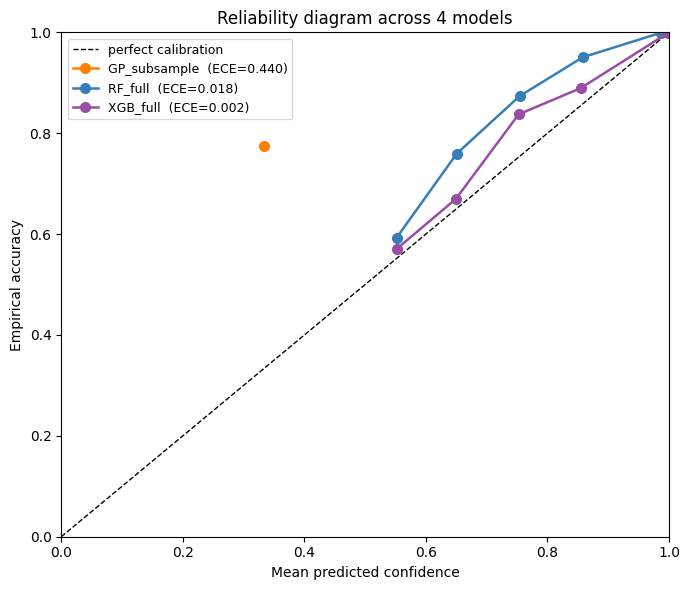

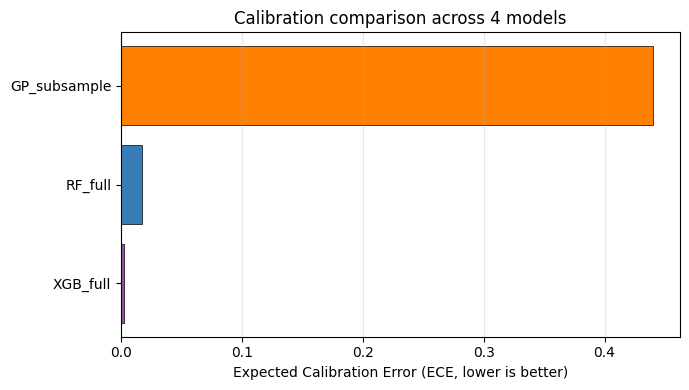

In [11]:
# ----------------------------------------------------------------------------
# 8. Calibration metrics: reliability diagram and ECE
# ----------------------------------------------------------------------------
# ECE measures whether confidence matches empirical accuracy. If a group of
# predictions has mean confidence 0.8, about 80% should be correct.

def reliability_bins(y_true, proba, pred, n_bins=10):
    confidence = proba.max(axis=1)
    correct = (pred == np.asarray(y_true)).astype(float)
    bins = np.linspace(0, 1, n_bins + 1)
    rows = []
    ece = 0.0
    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        if i == n_bins - 1:
            mask = (confidence >= lo) & (confidence <= hi)
        else:
            mask = (confidence >= lo) & (confidence < hi)
        n = int(mask.sum())
        if n == 0:
            rows.append({
                "bin": i,
                "lo": lo,
                "hi": hi,
                "n": 0,
                "mean_confidence": np.nan,
                "accuracy": np.nan,
                "abs_gap": np.nan,
            })
            continue
        mean_conf = float(confidence[mask].mean())
        acc = float(correct[mask].mean())
        gap = abs(acc - mean_conf)
        ece += (n / len(confidence)) * gap
        rows.append({
            "bin": i,
            "lo": lo,
            "hi": hi,
            "n": n,
            "mean_confidence": mean_conf,
            "accuracy": acc,
            "abs_gap": gap,
        })
    return pd.DataFrame(rows), float(ece)

calibration_rows = []
reliability_tables = {}

# GP calibration
gp_rel, gp_ece = reliability_bins(y_test.values, gp_proba, gp_pred, n_bins=10)
gp_rel["model"] = "GP_subsample"
reliability_tables["GP_subsample"] = gp_rel
calibration_rows.append({"model": "GP_subsample", "ece": gp_ece})

# Compare against Book 2 (RF / XGB) and Book 3 (GraphSAGE) probability maps.
# Each model saves a different filename pattern; this dispatcher handles them
# uniformly. We allow multiple filename glob patterns per model because the
# notebook version (v3) and the split-name (with or without val city) can vary.

OTHER_MODELS = [
    {
        "label": "RF_full",
        "globs": [
            "book2_v3_rf_predictions_cross_city_train_*_test_*.geojson",
            "book2_rf_predictions_cross_city_train_*_test_*.geojson",
        ],
        "prefix": "rf",
        "y_col": "true_weak_label",
    },
    {
        "label": "XGB_full",
        "globs": [
            "book2_v3_xgb_predictions_cross_city_train_*_test_*.geojson",
            "book2_xgb_predictions_cross_city_train_*_test_*.geojson",
        ],
        "prefix": "xgb",
        "y_col": "true_weak_label",
    },
    {
        "label": "GraphSAGE",
        "globs": [
            "book3_graphsage_predictions_cross_city_train_*_test_*.geojson",
        ],
        "prefix": "gnn",
        "y_col": "weak_label",                          # Book 3 saves as weak_label
        "filter_col": "is_test",                        # only keep test rows
    },
]

def find_first_match(globs):
    """Return the most recent file matching any of the given glob patterns."""
    for pattern in globs:
        candidates = sorted(OUTPUT_DIR.glob(pattern))
        # Avoid per-city files like *_chengdu_*.geojson — they are split-by-city
        # exports, not the full test prediction map. The full map has no city
        # name between 'predictions' and 'cross_city'.
        candidates = [p for p in candidates
                      if "_cross_city" in p.name.split("predictions")[-1][:15]]
        if candidates:
            return candidates[-1]
    return None

for spec in OTHER_MODELS:
    path = find_first_match(spec["globs"])
    if path is None:
        print(f"No {spec['label']} prediction map found; skipping.")
        continue
    pred_map = gpd.read_file(path)
    prefix = spec["prefix"]
    y_col = spec["y_col"]
    proba_cols = [f"{prefix}_prob_{CLASS_NAMES[c]}" for c in CLASS_ORDER]
    pred_col = f"{prefix}_prediction"
    needed = set(proba_cols + [pred_col, y_col])
    if not needed.issubset(pred_map.columns):
        missing = needed - set(pred_map.columns)
        print(f"{spec['label']}: missing columns {missing}, skipping.")
        continue
    # Filter to test rows if specified (Book 3 has train/val/test in same file)
    if spec.get("filter_col") and spec["filter_col"] in pred_map.columns:
        before = len(pred_map)
        pred_map = pred_map[pred_map[spec["filter_col"]].astype(bool)].copy()
        print(f"{spec['label']}: filtered {before} -> {len(pred_map)} test rows")
    pred_map = pred_map.dropna(subset=[y_col, pred_col] + proba_cols)
    model_proba = pred_map[proba_cols].to_numpy()
    model_pred = pred_map[pred_col].astype(int).to_numpy()
    model_y = pred_map[y_col].astype(int).to_numpy()
    rel, ece = reliability_bins(model_y, model_proba, model_pred, n_bins=10)
    rel["model"] = spec["label"]
    reliability_tables[spec["label"]] = rel
    calibration_rows.append({"model": spec["label"], "ece": ece})
    print(f"{spec['label']}: ECE = {ece:.3f}  (loaded from {path.name})")

calibration_df = pd.DataFrame(calibration_rows).sort_values("ece")
display(calibration_df)
calibration_df.to_csv(OUTPUT_DIR / f"book4_calibration_ece_{split_name}.csv", index=False)

all_rel = pd.concat(reliability_tables.values(), ignore_index=True)
all_rel.to_csv(OUTPUT_DIR / f"book4_reliability_bins_{split_name}.csv", index=False)

# Reliability diagram for all loaded models.
MODEL_COLORS = {
    "RF_full":      "#377eb8",   # blue
    "XGB_full":     "#984ea3",   # purple
    "GraphSAGE":    "#e41a1c",   # red (headline model)
    "GP_subsample": "#ff7f00",   # orange
}

plt.figure(figsize=(7, 6))
plt.plot([0, 1], [0, 1], "k--", lw=1, label="perfect calibration")
for model_name, rel in reliability_tables.items():
    rel_plot = rel.dropna(subset=["mean_confidence", "accuracy"])
    if len(rel_plot) == 0:
        continue
    ece_val = next(r["ece"] for r in calibration_rows if r["model"] == model_name)
    plt.plot(rel_plot["mean_confidence"], rel_plot["accuracy"],
             marker="o", markersize=7, lw=1.8,
             color=MODEL_COLORS.get(model_name, "gray"),
             label=f"{model_name}  (ECE={ece_val:.3f})")
plt.xlabel("Mean predicted confidence")
plt.ylabel("Empirical accuracy")
plt.title("Reliability diagram across 4 models")
plt.legend(loc="upper left", fontsize=9)
plt.xlim(0, 1); plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"book4_reliability_diagram_{split_name}.png", dpi=220)
plt.show()

# ECE bar chart with proper colors
plt.figure(figsize=(7, 4))
calibration_df_sorted = calibration_df.sort_values("ece")
bar_colors = [MODEL_COLORS.get(m, "gray") for m in calibration_df_sorted["model"]]
plt.barh(calibration_df_sorted["model"], calibration_df_sorted["ece"],
         color=bar_colors, edgecolor="black", linewidth=0.5)
plt.xlabel("Expected Calibration Error (ECE, lower is better)")
plt.ylabel("")
plt.title("Calibration comparison across 4 models")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"book4_ece_comparison_{split_name}.png", dpi=220)
plt.show()


### Step 9: Export high-confidence and high-uncertainty validation samples

**Purpose**: Create a compact set of GP-derived grids for manual inspection, focusing on confident village predictions and uncertain locations.  
**Input**: GP prediction map with village probability and entropy.  
**Output**: validation-sample GeoJSON and CSV for QGIS or browser-based checking.


In [12]:
# ----------------------------------------------------------------------------
# 9. Export high-uncertainty and high-confidence validation samples
# ----------------------------------------------------------------------------
# These are useful for manual checking:
# - high-confidence GP village predictions
# - high-entropy cells where the GP is uncertain

high_gp_village = out.sort_values("gp_village_probability", ascending=False).head(50)
high_gp_uncertain = out.sort_values("gp_pred_entropy", ascending=False).head(50)
gp_validation_sample = pd.concat(
    [
        high_gp_village.assign(sample_reason="gp_confident_village"),
        high_gp_uncertain.assign(sample_reason="gp_high_entropy"),
    ],
    ignore_index=True,
).drop_duplicates(subset=["grid_id", "city"])

gp_validation_sample.to_file(
    OUTPUT_DIR / f"book4_gp_validation_sample_{split_name}.geojson",
    driver="GeoJSON",
)
gp_validation_sample.drop(columns="geometry").to_csv(
    OUTPUT_DIR / f"book4_gp_validation_sample_{split_name}.csv",
    index=False,
)

print("Saved Book 4 outputs to:", OUTPUT_DIR)


Saved Book 4 outputs to: /content/drive/MyDrive/0069/week10/outputs
